# College Park Calendar Year 2024 Crash Data Analysis

**Data Source:** https://mdsp.maryland.gov/Pages/Dashboards/CrashDataDashboard.aspx
**Time Period:** Jan 2024 - Dec 2024

## Methodology

* Data will be extracted from the MSP Crash Data Dashboard.
* Crashes will be filtered to include only those occurring within the College Park municipal limits.
* Spatial analysis will be conducted to identify crash hotspots.
* Statistical analysis will be performed to identify trends related to:
* Most frequent crash locations (intersections, street segments).
* Common crash types (e.g., rear-end, angle, sideswipe).
* Time of day/day of week patterns.
* Contributing factors (e.g., distracted driving, speed, failure to yield).
* Injury severity distribution.
* Any inconsistencies or missing data points will be noted.
## Key Findings

## Data Preparation

Load libraries

In [2]:
import pandas as pd
import numpy as np
import geopandas
import matplotlib.pyplot as plt
import datetime
import math
from dateutil.relativedelta import relativedelta
from IPython.display import Image

### Load data

In [3]:
general_crash_data_2024 = pd.read_csv('./raw_data/CrashCounts_Reports_data.csv')
non_motorist_crash_data_2024 = pd.read_csv('./raw_data/CrashCounts_NonMotorists_data.csv')

C:\Users\pmedina\AppData\Local\Temp\ipykernel_5804\1072871256.py:1: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  general_crash_data_2024 = pd.read_csv('./raw_data/CrashCounts_Reports_data.csv')


In [4]:
non_motorist_crash_data_2024.head(5)

,Type NM Description,PersonID NM,ReportNumber NM,ActionPriorToCrash NM,ActionPriorToCrash NM Description,Age NM,City NM,ContactPoint NM,ContactPoint NM Description,DistractedByAction NM,...,InjuryStatus NM Description,Location NM,Location NM Description,OriginDestination NM,OriginDestination NM Description,State NM,StruckByVehID NM,Type NM,Unknown NM,ZipCode NM
0,Cyclist (non-electric),ebbd3c7c-cd77-49da-873b-cada6a4576e5,AA0073002X,6,Walking/Cycling Along Roadway With Traffic (In...,19,ABERDEEN,3,Right,0,...,Suspected Minor Injury,3,Intersection – Other,2,Transit,MD,13a105ad-040f-43c8-979f-b8d05d497f3f,101,N,21001
1,Pedestrian,bef84824-8980-483e-a8fa-85037292daae,AA0073003H,98,Other,57,EDGEWOOD,12,Front,0,...,Suspected Minor Injury,98,Other,97,Not Applicable,MD,619dc5f9-4e02-4e2d-8a3c-fb24a2cfd35a,6,N,21009
2,Pedestrian,1a8f99d7-1ef8-4711-b94d-82077f3d1621,AA00850047,101,Cross/Enter Not at Intersection,47,ABERDEEN,3,Right,99,...,Fatal Injury,7,Travel Lane – Other Location,97,Not Applicable,MD,21812834-6dd1-4026-aeb2-cdab9b734017,6,N,21001
3,Cyclist (Electric),4918bb20-61cf-4d08-a1c9-6f700bbc195b,AA0085004K,6,Walking/Cycling Along Roadway With Traffic (In...,32,ABERDEEN,9,Left,0,...,Suspected Minor Injury,3,Intersection – Other,97,Not Applicable,MD,b8de8cc1-3e29-45c4-b166-87bd782b39be,100,N,21001
4,Pedestrian,7957d0d1-8da9-42da-bd6f-5b5e815bfd7f,AA01230052,100,Cross/Enter at Intersection,48,ABERDEEN,9,Left,0,...,Suspected Minor Injury,1,Intersection – Marked Crosswalk,97,Not Applicable,MD,cfd16d36-8693-42ef-8825-7eb8356b08ba,6,N,21001


In [5]:
general_crash_data_2024.head(5)

,Crash County Description,Crash Severity Description,Reportnumber,Agencyname,CollisionImpact Description,FunctionalClass Description,ImpairedCrash,Large Vehicle Involved,Motorcycle Crash,Non-Motorist Crash,...,Surface Description,TrafficControl,Trafficcontrol Description,Work Zone Crash,WZLawEnforcementPresent,WZLocation,WZLocation Description,WZType,WZType Description,WZWorkersPresent
0,St. Mary's,Property Damage Crashes,ZR0390003K,Saint Mary's County Sheriff's Office,Single Vehicle,Major Collector,No,No,No,No,...,Wet,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN
1,Charles,Injury Crashes,MSP77400007,Maryland State Police,Single Vehicle,Major Collector,No,No,No,No,...,Dry,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN
2,Frederick,Property Damage Crashes,MSP743400JS,Maryland State Police,"Sideswipe, Same Direction",Interstate,No,Yes,No,No,...,Dry,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN
3,Harford,Fatal Crashes,MSP713100CG,Maryland State Police,Single Vehicle,Interstate,No,No,No,No,...,Wet,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN
4,Anne Arundel,Injury Crashes,AC2586001Q,Anne Arundel County Police,Front to Rear,Local,No,No,No,No,...,Dry,1.0,Signalized,No,NaN,NaN,NaN,NaN,NaN,NaN


### Consolidate datasets

Merge both datasets by report number.

In [6]:
consolidated_crash_data_2024 = general_crash_data_2024.merge(non_motorist_crash_data_2024, left_on='Reportnumber', right_on='ReportNumber NM', how='left')

### Clip data to College Park limits

Clip features to CP boundaries.

Load CP boundaries.

In [37]:
cp = geopandas.read_file("data/boundaries/College_Park_City_Limits.shp")
cp = cp.to_crs(4326)
cp.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [38]:
#Load consolidated dataset as geopandas object
gdf = geopandas.GeoDataFrame(
    consolidated_crash_data_2024, geometry=geopandas.points_from_xy(consolidated_crash_data_2024.Longitude, consolidated_crash_data_2024.Latitude), crs="EPSG:26985"
)

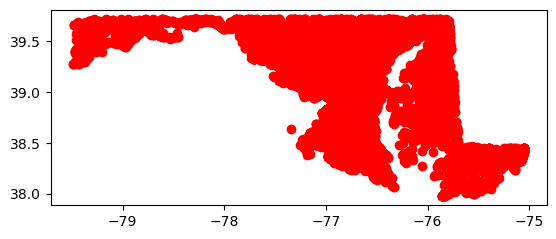

In [39]:
ax = cp.plot(color="white", edgecolor="black")

# We can now plot our ``GeoDataFrame``.
gdf.plot(ax=ax, color="red")

plt.show()

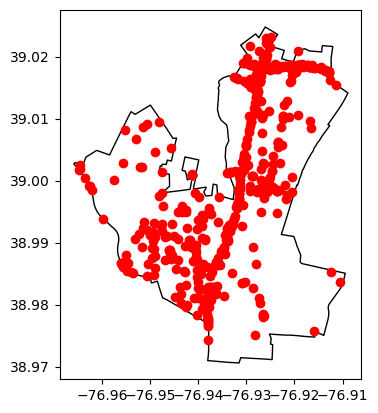

In [10]:
#Clip dataset
consolidated_CP_crash_data_2024 = geopandas.clip(gdf, cp)
ax = cp.plot(color="white", edgecolor="black") #Load boundaries
consolidated_CP_crash_data_2024.plot(ax=ax, color="red") #Load clipped points

plt.show() #Plot

In [11]:
#Save dataset
consolidated_CP_crash_data_2024.to_csv('tidy_data/consolidated_data.csv')

## Analysis

### Time series

In [12]:
consolidated_CP_crash_data_2024.head(5)

,Crash County Description,Crash Severity Description,Reportnumber,Agencyname,CollisionImpact Description,FunctionalClass Description,ImpairedCrash,Large Vehicle Involved,Motorcycle Crash,Non-Motorist Crash,...,Location NM,Location NM Description,OriginDestination NM,OriginDestination NM Description,State NM,StruckByVehID NM,Type NM,Unknown NM,ZipCode NM,geometry
105324,Prince George's,Injury Crashes,DA418100DD,Prince George's County Police,Other,Principal Arterial – Other,No,No,No,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-76.938 38.974)
56693,Prince George's,Property Damage Crashes,DA4050005V,Prince George's County Police,Single Vehicle,NaN,No,No,No,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-76.928 38.975)
42792,Prince George's,Property Damage Crashes,DA14540004,Prince George's County Police,Single Vehicle,Local,No,No,No,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-76.916 38.976)
16239,Prince George's,Property Damage Crashes,DA418600BK,Prince George's County Police,"Sideswipe, Same Direction",Principal Arterial – Other,No,No,No,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-76.938 38.976)
59128,Prince George's,Property Damage Crashes,DA43790012,Prince George's County Police,Rear To Side,Principal Arterial – Other,No,No,No,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-76.938 38.977)


In [13]:
consolidated_CP_crash_data_2024['Crashdate']

105324     6/28/2024
56693       5/4/2024
42792      1/20/2024
16239      12/5/2024
59128     11/20/2024
             ...    
89129      7/29/2024
75486      7/23/2024
22930      12/7/2024
70137      6/13/2024
52352     12/20/2024
Name: Crashdate, Length: 542, dtype: object

In [14]:
consolidated_CP_crash_data_2024['Crashdate'] = pd.to_datetime(consolidated_CP_crash_data_2024.Crashdate)

C:\Users\pmedina\AppData\Local\anaconda3\Lib\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [15]:
consolidated_CP_crash_data_2024['month_n'] = consolidated_CP_crash_data_2024['Crashdate'].dt.strftime("%m")
consolidated_CP_crash_data_2024['month_name'] = consolidated_CP_crash_data_2024['Crashdate'].dt.strftime("%B")

C:\Users\pmedina\AppData\Local\anaconda3\Lib\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\pmedina\AppData\Local\anaconda3\Lib\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


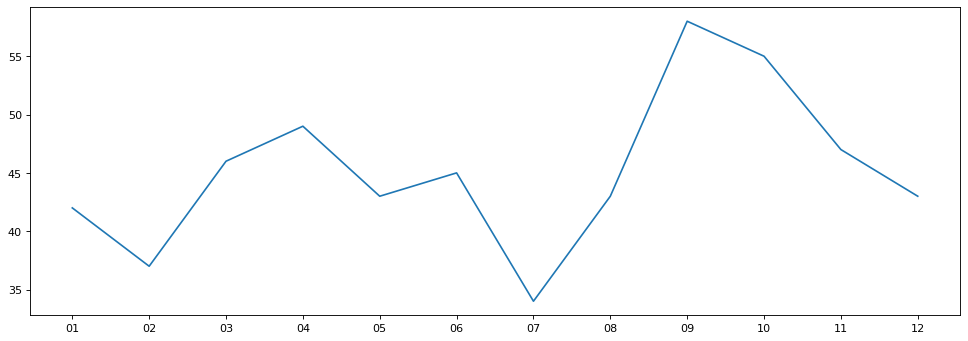

In [16]:
from matplotlib.pyplot import figure
figure(figsize=(15, 5), dpi=80)
plt.plot(consolidated_CP_crash_data_2024.groupby('month_n')['Reportnumber'].count())


### Clustering
Clustering analysis was done based on:
* General accident distribution
* Distribution based on crash severity
* Distribution based on non-motorists crashes

#### General accident distribution

#### Distribution based on crash severity

Based on the results, the crash severity does not have a clustering pattern

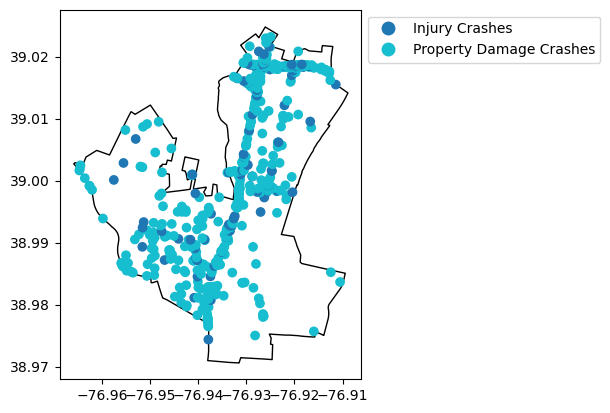

In [17]:
ax = cp.plot(color="white", edgecolor="black") #Load boundaries
consolidated_CP_crash_data_2024.plot(ax=ax, 
                                     column='Crash Severity Description', 
                                     legend=True,
                                    legend_kwds={'bbox_to_anchor': (1, 1)}) 
#Load clipped points with symbology by crash severity

plt.show() #Plot

##### ArcGIS Pro Cluster analysis

In [18]:
Image(url="images/crash_severity_cluster_analisys.png", width=500)

## Intersection crash analysis

Using the intersection boundaries and creating a 50 meters buffer around them, I will count the accidents per intersection.

In [52]:
crash_per_intersection = pd.read_csv("./raw_data/Crash_Incidents_per_Intersection.csv")

In [54]:
crash_per_intersection = crash_per_intersection.dropna(subset=['mean_Crashhour'])
crash_per_intersection.head(5)

,ADDRESS,TYPE,WALK_LIGHT,BUFF_DIST,ORIG_FID,Shape_Length,Shape_Area,mean_Crashhour,std_Crashhour,mean_Age_NM,Point_Count,Minority_Crash_Severity_Description,Majority_Crash_Severity_Description,Minority_Crash_Severity_Description_Percent,Majority_Crash_Severity_Description_Percent,Join_ID
0,Rhode Island Ave & Edgewood Rd,Bar,Yes,164.041667,1,1189.574437,111197.643646,16.0,1.414214,NaN,2,Property Damage Crashes,Property Damage Crashes,100.000000,100.000000,1
1,Rhode Island Ave & Paducah Rd,Zebra Stripe,No,164.041667,2,1129.851496,101050.495539,15.0,0.000000,NaN,1,Property Damage Crashes,Property Damage Crashes,100.000000,100.000000,2
3,Rhode Island Ave & Niagara Rd,Zebra Stripe,No,164.041667,4,1111.145618,97956.631287,13.0,11.135529,NaN,3,Injury Crashes,Property Damage Crashes,33.333333,66.666667,4
4,Rhode Island Ave & Niagara Rd,Zebra Stripe,No,164.041667,5,1091.027321,94559.953856,11.5,9.574271,NaN,4,Injury Crashes,Property Damage Crashes,25.000000,75.000000,5
9,Edgewood Rd & Rhode Island Ave,Bar,Yes,164.041667,10,1165.606626,107177.145069,16.0,1.414214,NaN,2,Property Damage Crashes,Property Damage Crashes,100.000000,100.000000,10


In [57]:
crash_per_intersection = crash_per_intersection.sort_values(by=['Point_Count'], ascending=False)
crash_per_intersection.head(10)

,ADDRESS,TYPE,WALK_LIGHT,BUFF_DIST,ORIG_FID,Shape_Length,Shape_Area,mean_Crashhour,std_Crashhour,mean_Age_NM,Point_Count,Minority_Crash_Severity_Description,Majority_Crash_Severity_Description,Minority_Crash_Severity_Description_Percent,Majority_Crash_Severity_Description_Percent,Join_ID
92,Ikea Way & Baltimore Ave,Bar,Yes,164.041667,93,1112.808813,98258.131848,12.769231,6.379052,NaN,13,Injury Crashes,Property Damage Crashes,7.692308,92.307692,93
93,Ikea Way & Baltimore Ave,Bar,Yes,164.041667,94,1152.655682,104954.430447,12.769231,6.379052,NaN,13,Injury Crashes,Property Damage Crashes,7.692308,92.307692,94
94,Baltimore Ave,Bar,Yes,164.041667,95,1209.181331,114553.351531,12.769231,6.379052,NaN,13,Injury Crashes,Property Damage Crashes,7.692308,92.307692,95
97,Baltimore Ave,Zebra Stripe,No,164.041667,98,1090.691697,94541.256021,13.923077,6.143581,NaN,13,Injury Crashes,Property Damage Crashes,15.384615,84.615385,98
95,Baltimore Ave,Bar,Yes,164.041667,96,1200.483361,113058.516464,13.583333,5.915439,NaN,12,Injury Crashes,Property Damage Crashes,8.333333,91.666667,96
73,Baltimore Ave & Cherry Hill Rd,Bar,Yes,164.041667,74,1184.988758,110280.569459,14.181818,6.493353,57.0,11,Injury Crashes,Property Damage Crashes,36.363636,63.636364,74
43,University Blvd & Rhode Island Ave,Zebra Stripe,Yes,164.041667,44,1205.007882,113817.940071,17.300000,4.498148,NaN,10,Injury Crashes,Property Damage Crashes,10.000000,90.000000,44
44,Rhode Island Ave & University Blvd,Zebra Stripe,Yes,164.041667,45,1131.559212,101430.532508,17.300000,4.498148,NaN,10,Injury Crashes,Property Damage Crashes,10.000000,90.000000,45
75,SB Cap Belt Hwy & Baltimore Ave,Zebra Stripe,No,164.041667,76,1124.094318,100184.353054,12.555556,7.401201,NaN,9,Property Damage Crashes,Property Damage Crashes,100.000000,100.000000,76
54,NaN,NaN,NaN,164.041667,55,1138.620439,102688.863120,13.111111,8.666667,NaN,9,Property Damage Crashes,Property Damage Crashes,100.000000,100.000000,55


In [58]:
crash_per_intersection.to_csv("tidy_data/crash_per_intersection.csv")